## Creating a Logistic Regression Model

### Discovery

Welcome new data analyst contractor, to day 2 at Ethical Oil Inc! The humble management team were incredibly impressed with your previous efforts in creating a linear regression model to demonstrate how the close price of the S&P 500 will impact the price of oil. <br><br>
They would now like you to take this knowledge even further and would like you to understand if it's possible to predict whether the cost of oil will reach a certain threshold. Being the ever intelligent and resourceful contractor that you are, you know that you can do this with logistic regression, but have overpromised and said you will deliver them the model today, in exchange for additional paid leave. Happily, the data has already been loaded and transformed from your earlier efforts and you will just need to build the model and analyse the results. 

First we will import the required modules. They are:
- pandas
- seaborn
- statsmodels.api
- sklearn.model_selection - train_test_split
- sklearn.metrics - confusion_matrix
- matplotlib.pyplot

In [2]:
# Import required modules
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

--- 
### Data preparation
All data cleaning steps are identical to the steps taken for Linear Regression, as we are using the same dataset. We begin by importing the stocks dataset. Set the index column as the "Date". Remember to validate the import has worked.

In [3]:
# Import the first dataset and set the date as the index
df = pd.read_csv("df_fuel_ckan.csv", index_col = "DATETIME", parse_dates=True)
df.head()

,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,SOLAR,...,IMPORTS_perc,BIOMASS_perc,OTHER_perc,SOLAR_perc,STORAGE_perc,GENERATION_perc,LOW_CARBON_perc,ZERO_CARBON_perc,RENEWABLE_perc,FOSSIL_perc
DATETIME,,,,,,,,,,,,,,,,,,,,,
2009-01-01 00:00:00,8367.0,15037.0,7099.0,248.0,62.0,246.0,2518.0,0.0,0.0,0.0,...,7.5,0.0,0.0,0.0,0.0,100.0,22.8,24.5,1.7,69.7
2009-01-01 00:30:00,8495.0,15095.0,7088.0,229.0,57.0,245.0,2495.0,0.0,0.0,0.0,...,7.4,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.6,70.0
2009-01-01 01:00:00,8471.0,15088.0,7074.0,207.0,52.0,246.0,2465.0,0.0,0.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.2,1.5,70.1
2009-01-01 01:30:00,8318.0,15035.0,7064.0,191.0,48.0,246.0,2439.0,0.0,0.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.5,70.0
2009-01-01 02:00:00,8295.0,15005.0,7052.0,175.0,44.0,246.0,2363.0,0.0,0.0,0.0,...,7.1,0.0,0.0,0.0,0.0,100.0,22.7,24.3,1.4,70.2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 305103 entries, 2009-01-01 00:00:00 to 2026-05-28 07:00:00
Data columns (total 33 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   GAS               305103 non-null  float64
 1   COAL              305103 non-null  float64
 2   NUCLEAR           305103 non-null  float64
 3   WIND              305103 non-null  float64
 4   WIND_EMB          305103 non-null  float64
 5   HYDRO             305103 non-null  float64
 6   IMPORTS           305103 non-null  float64
 7   BIOMASS           305103 non-null  float64
 8   OTHER             305103 non-null  float64
 9   SOLAR             305103 non-null  float64
 10  STORAGE           305103 non-null  float64
 11  GENERATION        305103 non-null  float64
 12  CARBON_INTENSITY  305103 non-null  float64
 13  LOW_CARBON        305103 non-null  float64
 14  ZERO_CARBON       305103 non-null  float64
 15  RENEWABLE         305103 non-null 

Import the oil dataset, set the index column as "date". Remember to validate the import has worked. 

In [5]:
# Import the second dataset and set the date as the index
df = df[["GAS","COAL","NUCLEAR","WIND","HYDRO","SOLAR","CARBON_INTENSITY"]]
df.head()

,GAS,COAL,NUCLEAR,WIND,HYDRO,SOLAR,CARBON_INTENSITY
DATETIME,,,,,,,
2009-01-01 00:00:00,8367.0,15037.0,7099.0,248.0,246.0,0.0,524.0
2009-01-01 00:30:00,8495.0,15095.0,7088.0,229.0,245.0,0.0,526.0
2009-01-01 01:00:00,8471.0,15088.0,7074.0,207.0,246.0,0.0,527.0
2009-01-01 01:30:00,8318.0,15035.0,7064.0,191.0,246.0,0.0,527.0
2009-01-01 02:00:00,8295.0,15005.0,7052.0,175.0,246.0,0.0,528.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 305103 entries, 2009-01-01 00:00:00 to 2026-05-28 07:00:00
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   GAS               305103 non-null  float64
 1   COAL              305103 non-null  float64
 2   NUCLEAR           305103 non-null  float64
 3   WIND              305103 non-null  float64
 4   HYDRO             305103 non-null  float64
 5   SOLAR             305103 non-null  float64
 6   CARBON_INTENSITY  305103 non-null  float64
dtypes: float64(7)
memory usage: 18.6 MB


--- 
### Model planning
We can begin to explore our data by looking at the average values for our dependent (output) variable, which will help us to understand what the distribution of data may look like.

In [7]:
# Get the mean and median prices from the dataset and print them in a single line of code. 
mean_price = df["CARBON_INTENSITY"].mean()
med_price = df["CARBON_INTENSITY"].median()
print(f"The mean price is {mean_price} and the median price is {med_price}.")

The mean price is 288.17269577814704 and the median price is 252.0.


Next we want to create a histogram to understand the distribution of price, to understand what high prices might look like. Once we have this, we can create a binary field in our dataset, showing us whether we have hit the threshold or not. 

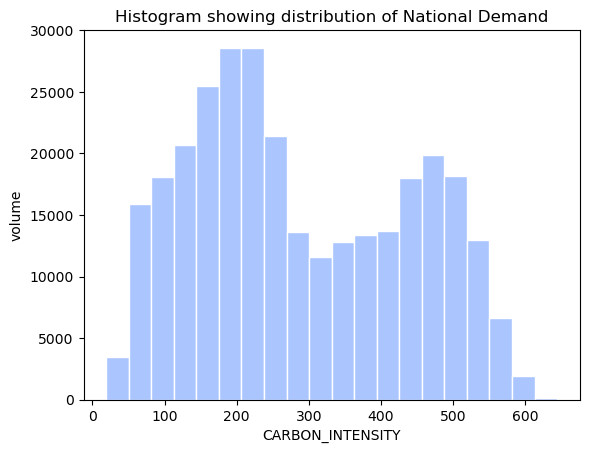

In [8]:
# Create a histogram to determine a suitable threshold for high oil costs. 
hist = sns.histplot(x = "CARBON_INTENSITY",
             data = df,
             color="#8FB2FF",
             edgecolor="White",
             bins=20)
hist.set_ylabel("volume")
hist.set_title("Histogram showing distribution of National Demand")
plt.show()

Our histogram has a positive (right) skew and is bimodal. We can see the distribution of oil costs has two clear clusters. The main cluster (left) which has typically has a range of $45-$65, and second cluster (right) which has a range of $90-$110. With the main cluster containing the majority of our data, and with an outlier in $80, per barrell we can determine high costs of oil will be where oil costs $90 or more. This is where we will set our threshold for a True outcome. 

In [9]:
# Create a new binary column in the dataframe which will be True/False based on the threshold. 
df["HIGH_CARBON"] = df["CARBON_INTENSITY"] >= 450
df.head()

,GAS,COAL,NUCLEAR,WIND,HYDRO,SOLAR,CARBON_INTENSITY,HIGH_CARBON
DATETIME,,,,,,,,
2009-01-01 00:00:00,8367.0,15037.0,7099.0,248.0,246.0,0.0,524.0,True
2009-01-01 00:30:00,8495.0,15095.0,7088.0,229.0,245.0,0.0,526.0,True
2009-01-01 01:00:00,8471.0,15088.0,7074.0,207.0,246.0,0.0,527.0,True
2009-01-01 01:30:00,8318.0,15035.0,7064.0,191.0,246.0,0.0,527.0,True
2009-01-01 02:00:00,8295.0,15005.0,7052.0,175.0,246.0,0.0,528.0,True


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 305103 entries, 2009-01-01 00:00:00 to 2026-05-28 07:00:00
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   GAS               305103 non-null  float64
 1   COAL              305103 non-null  float64
 2   NUCLEAR           305103 non-null  float64
 3   WIND              305103 non-null  float64
 4   HYDRO             305103 non-null  float64
 5   SOLAR             305103 non-null  float64
 6   CARBON_INTENSITY  305103 non-null  float64
 7   HIGH_CARBON       305103 non-null  bool   
dtypes: bool(1), float64(7)
memory usage: 18.9 MB


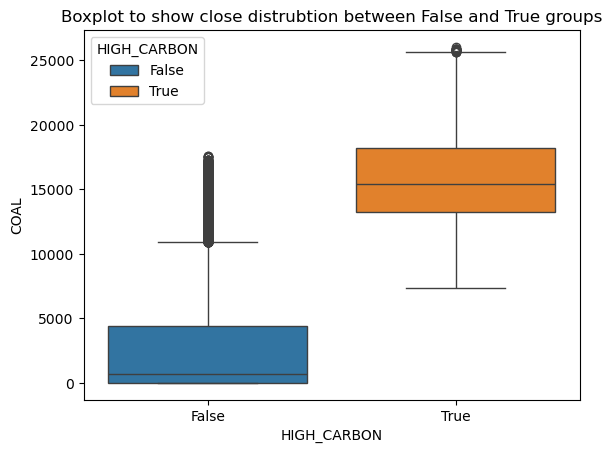

In [11]:
# Create a box plot to show the differences in distribution between your true and false groups. 
box = sns.boxplot(x = "HIGH_CARBON",
                  y = "COAL",
                  data = df,
                  hue = "HIGH_CARBON")

# Set title
box.set_title("Boxplot to show close distrubtion between False and True groups")
plt.show()

Finally, a correlation matrix will help us to see if there is a strong relationship between our dependent (output) variable and our binary independent (input) variable. 

<Axes: >

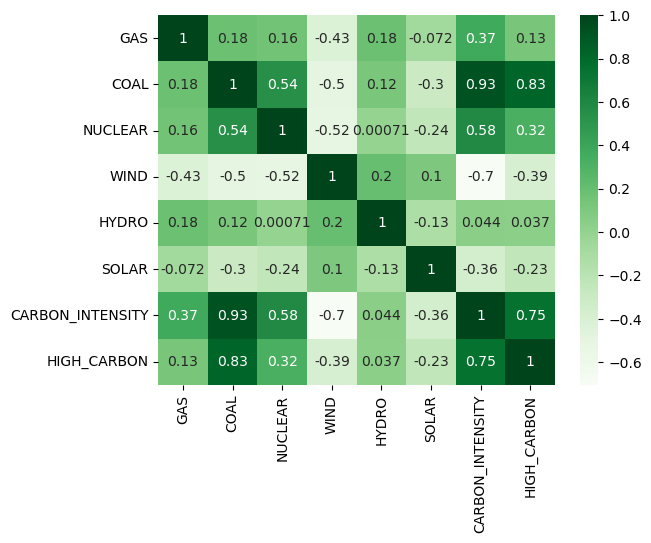

In [12]:
# Create a correlation matrix to demonstrate relationships between our variables. 
carbon_corr = df.corr()
sns.heatmap(carbon_corr, annot=True, cmap="Greens")

---
### Building the model

Building the data model is almost exactly the same as the process for Linear Regression. First, we split our data into training and test datasets. We set out dependent (output) variable, this time as our binary field. We then set our independent (input) variable, add the constant, and feed them both into the model function. This time, instead of using an OLS function, we will be using a Logit function. 

In [14]:
# Split the data into train and test samples
train, test = train_test_split(df,random_state=25)

Set both the independent variable and dependent variable - remember to check they are set correctly. Don't forget to add a constant to your independent variables. 

In [15]:
# Set the dependent variable and validate
dep = train["HIGH_CARBON"]
dep.head()

DATETIME
2012-01-31 13:00:00     True
2015-03-16 11:00:00     True
2021-02-07 13:00:00    False
2009-05-15 23:00:00    False
2023-06-05 11:30:00    False
Name: HIGH_CARBON, dtype: bool

In [16]:
# Set the independent variable and validate
ind = train["COAL"]
ind.head()

DATETIME
2012-01-31 13:00:00    24527.0
2015-03-16 11:00:00    16075.0
2021-02-07 13:00:00      316.0
2009-05-15 23:00:00     7850.0
2023-06-05 11:30:00        0.0
Name: COAL, dtype: float64

In [17]:
# Remember to add the constant 
ind = sm.add_constant(ind)
ind.head()

,const,COAL
DATETIME,,
2012-01-31 13:00:00,1.0,24527.0
2015-03-16 11:00:00,1.0,16075.0
2021-02-07 13:00:00,1.0,316.0
2009-05-15 23:00:00,1.0,7850.0
2023-06-05 11:30:00,1.0,0.0


Now generate the logistic regression model along with a summary output. 

In [18]:
# Fit the model and produce the summary
model = sm.Logit(dep,ind).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.111844
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            HIGH_CARBON   No. Observations:               228827
Model:                          Logit   Df Residuals:                   228825
Method:                           MLE   Df Model:                            1
Date:                Thu, 04 Jun 2026   Pseudo R-squ.:                  0.7820
Time:                        14:43:24   Log-Likelihood:                -25593.
converged:                       True   LL-Null:                   -1.1740e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.3350      0.061   -153.021      0.000      -9.455      -9.215
COAL           0.0008   5.07e-06    155.712      0.000       0.001       0.001
==============================================================================

Possibly complete quasi-separation: A fraction 0.28 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

--- 
### Communicating the results. 
You will now analyse the model and communicate the results. What do the following outputs tell you about the model

- Pseudo R-Squared: Best used to check the goodness of fit, when comparing models. Pseudo R-Squared does not account for variance. 
- P-Value: When below 0.05, we infer the independent variable is deemed to have a significant relationship with the dependent varaible. 
- Coefficient: In our case the independent variable coefficient is negative. This means as increase the independent variable, the log-odds, and therefore the likelihood of a positive outcome is reduced. 

In [19]:
# Use the model to predict which dates we are likely to hit high oil prices. Check the output. 
predictions = model.predict(ind) >= 0.5
predictions.head()

DATETIME
2012-01-31 13:00:00     True
2015-03-16 11:00:00     True
2021-02-07 13:00:00    False
2009-05-15 23:00:00    False
2023-06-05 11:30:00    False
dtype: bool

Once we have our preductions - we can use these to create a confusion matrix, which will help us to assess the model quality. 

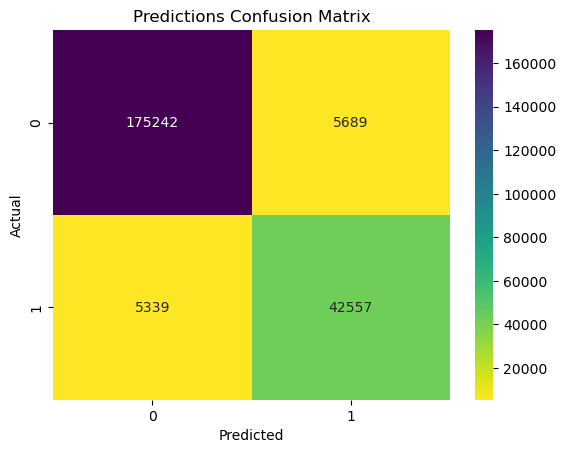

In [20]:
# Generate a confusion matrix to test the model.
conf_mat = confusion_matrix(dep, predictions)
conf_mat

# (Optional) Generate the confusion matrix as a heatmap
confusion_mat_heatmap = sns.heatmap(conf_mat, annot = True, cmap = 'viridis_r', fmt='g')

# (Optional) set x and y labels, and create a title
confusion_mat_heatmap.set_xlabel('Predicted')
confusion_mat_heatmap.set_ylabel('Actual')
confusion_mat_heatmap.set_title("Predictions Confusion Matrix")
plt.show()

**Basic Terminology**

**True Positives (TP)** is 42557: The model correctly predicted a large purchase. (Bottom right)

**True Negatives (TN)** is 175242: The model correctly predicted that it wont be a large purchase. (Top left)

**False Positives (FP)** is 5689: The model incorrectly predicted a large purchase. (Top right)

**False Negatives (FN)** is 5339: The model incorrectly predicted it wont be a large purchase. (Bottom left)

In [26]:
correct = 175242 + 42557 
incorrect = 5689 + 5339
all = (175242 + 5689 + 5339 + 42557)
print(correct)
print(incorrect)
print(all)
print(correct / all * 100)

217799
11028
228827
95.18063864841125


The model was correct in = 217799 cases; 

The model was incorrect in 11028 cases. 

Total = 228827 cases

That's a great overall success rate! 
217799/228827 * 100 = 95.18% accuracy

In [27]:
# Format floats to return values to a maximum of x decimal places 
pd.set_option('display.float_format', '{:.10f}'.format) 

# Check incorrectly predicted rows
output = model.predict(ind) >= 0.5 # Binary outputs
out2 = model.predict(ind) # Model prediction confidence outputs

# Concert outputs to dataframe columns for comparison
train["predicted"] = output
train['predicted_num'] = out2 

# Check model accurate (or inaccurate) predictions
inc_diff = train[train["HIGH_CARBON"] != train["predicted"]]
inc_diff

,GAS,COAL,NUCLEAR,WIND,HYDRO,SOLAR,CARBON_INTENSITY,HIGH_CARBON,predicted,predicted_num
DATETIME,,,,,,,,,,
2013-12-21 09:30:00,6096.0000000000,13215.0000000000,7368.0000000000,5750.0000000000,732.0000000000,95.0000000000,409.0000000000,False,True,0.7512589824
2014-02-08 10:00:00,5507.0000000000,14768.0000000000,7087.0000000000,5706.0000000000,1002.0000000000,855.0000000000,419.0000000000,False,True,0.9115139826
2011-05-06 12:00:00,19853.0000000000,11426.0000000000,7185.0000000000,746.0000000000,96.0000000000,0.0000000000,464.0000000000,True,False,0.4235946225
2013-07-17 14:00:00,13958.0000000000,13064.0000000000,8220.0000000000,752.0000000000,124.0000000000,1348.0000000000,448.0000000000,False,True,0.7283056140
2010-04-27 17:00:00,20836.0000000000,10748.0000000000,6564.0000000000,765.0000000000,358.0000000000,0.0000000000,455.0000000000,True,False,0.3007607326
...,...,...,...,...,...,...,...,...,...,...
2014-01-03 11:30:00,6654.0000000000,16169.0000000000,8107.0000000000,5585.0000000000,769.0000000000,519.0000000000,428.0000000000,False,True,0.9689044506
2010-06-02 10:30:00,20968.0000000000,10400.0000000000,6058.0000000000,534.0000000000,312.0000000000,0.0000000000,452.0000000000,True,False,0.2462691884
2014-12-30 08:30:00,9723.0000000000,13579.0000000000,7758.0000000000,2417.0000000000,716.0000000000,27.0000000000,446.0000000000,False,True,0.8010565426


In [28]:
# Test the model 
dep_test = test["HIGH_CARBON"]
ind_test = test["COAL"]
ind_test = sm.add_constant(ind_test)

# Produce the output and save to a dataframe column - then validate
output = model.predict(ind_test) >= 0.5
y_score = model.predict(ind_test)
test["predicted"] = output

# (Optional) Create a dataframe where only incorrect predictions are displayed
test = test[["COAL","HIGH_CARBON","predicted"]]
inc_diff = test[test["HIGH_CARBON"] != test["predicted"]]
inc_diff

,COAL,HIGH_CARBON,predicted
DATETIME,,,
2010-05-08 13:30:00,9256.0000000000,True,False
2010-02-05 02:30:00,11500.0000000000,True,False
2014-12-20 21:30:00,13677.0000000000,False,True
2014-04-14 08:00:00,15010.0000000000,False,True
2013-04-16 15:00:00,15878.0000000000,False,True
...,...,...,...
2012-12-31 08:30:00,13984.0000000000,False,True
2015-01-14 17:30:00,16340.0000000000,False,True
2010-04-26 20:00:00,10534.0000000000,True,False


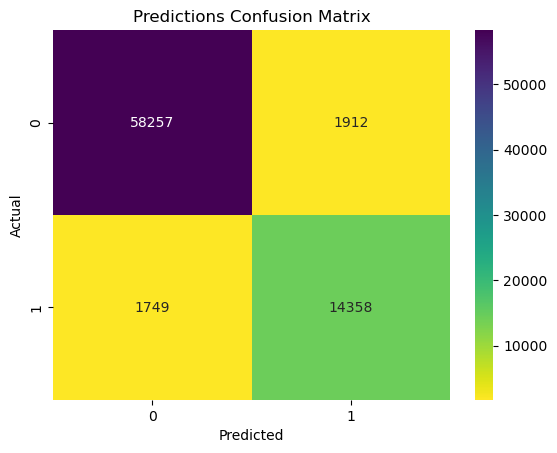

In [29]:
# Create a confusion matrix to display test results

tconf_mat = confusion_matrix(dep_test,output)
tconf_mat

# (Optional) Replicate the results as a heatmap as before:
tconfusion_mat_heatmap = sns.heatmap(tconf_mat, annot = True, cmap = 'viridis_r', fmt='g')

# (Optional) set x and y labels, and create a title
tconfusion_mat_heatmap.set_xlabel('Predicted')
tconfusion_mat_heatmap.set_ylabel('Actual')
tconfusion_mat_heatmap.set_title("Predictions Confusion Matrix")
plt.show()

--- 
### Operationalise
In the real world, this is where you would draft a report, deliver briefings, implement with automation on production level servers, produce technical documentation and build this into your BAU process. This being a fictional company, the ever grateful management have granted you paid leave for all your hard work and have volunteered to take on this burden themselves. Congratulations and well done!

--- 
### Stretch Tasks

By this stage, you have done everything required for CPD, but you can go further in your exploration of data, and analysis of the model. In this section we will:
- Produce a table of aggregates to look at the mean values for our 
- Create a histogram with the continuous probability density curve
- Create a Receiver Operating Characteristic (ROC) curve, which is used to plot the True Positives, against the False positives.


In [30]:
# Create aggregate table on the true/false column. Find the mean value. Variables should have distinct differences in the mean.
df.groupby("HIGH_CARBON").mean()

,GAS,COAL,NUCLEAR,WIND,HYDRO,SOLAR,CARBON_INTENSITY
HIGH_CARBON,,,,,,,
False,11590.3925093322,2653.3440190792,5983.8046619660,4890.0594898382,390.8353795106,1205.5267482372,230.5012525923
True,13300.8977547927,15849.3297189194,7215.1662109589,1219.1102760808,413.0714341515,75.9830007968,505.4216521101


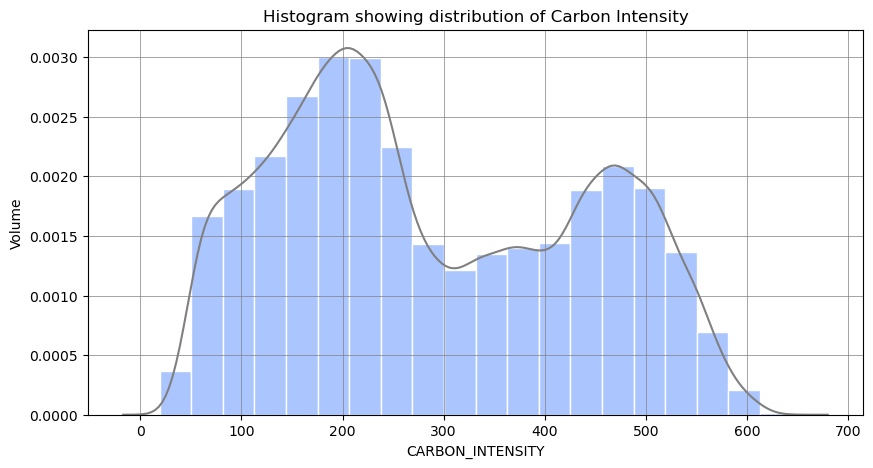

In [33]:
# Optional stylised output with a KDE... "...KDE represents the data using a continuous probability density curve in one or more dimensions".
# Fig represents the overall plot area, whereas ax represents everythinf cont
fig, ax = plt.subplots(figsize=(10,5))
plt.grid(visible = True, linestyle = "-",linewidth = 0.5, color = "grey")

sns.histplot(
    x="CARBON_INTENSITY",
    data=df,
    color="#8FB2FF",
    bins=20,
    edgecolor="White",
    stat="density",
    ax=ax
)

sns.kdeplot(
    x="CARBON_INTENSITY",
    data=df,
    color="grey",
    linewidth=1.5,
    ax=ax
)

ax.set_ylabel("Volume")
ax.set_title("Histogram showing distribution of Carbon Intensity")
plt.show()

In [34]:
# Calculate the false positive rate (fpr), true positive rate (tpr) and thesholds whereby the model will predict a true positive.
fpr, tpr, thresholds = roc_curve(dep_test, y_score)


# Validate they have been calculated correctly
print(fpr)
print(tpr)
print(thresholds)

[0.         0.         0.         ... 0.66181921 0.66318204 1.        ]
[0.00000000e+00 6.20848078e-05 1.92462904e-03 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
[           inf 9.99984793e-01 9.99970911e-01 ... 8.84138886e-05
 8.83440723e-05 8.82743111e-05]


In [35]:
# Calculate the area under curve (AUC) using the sklearn metric. 
roc_auc = auc(fpr, tpr)
print(f'The area under curve is calculated as {roc_auc}')

The area under curve is calculated as 0.9884908274073988


In [36]:
# Put the data into a dataframe, ready for visualisation. Then validate
roc_df = pd.DataFrame({
    "False Positive Rate": fpr,
    "True Positive Rate": tpr
})
roc_df.head()

,False Positive Rate,True Positive Rate
0,0.0000000000,0.0000000000
1,0.0000000000,0.0000620848
2,0.0000000000,0.0019246290
3,0.0000000000,0.0020487987
4,0.0000000000,0.0042217669


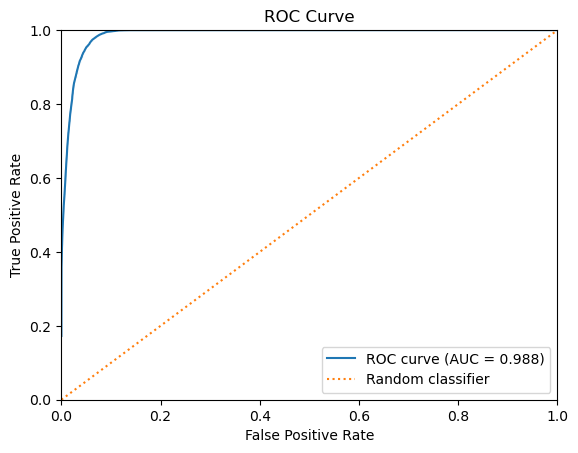

In [37]:
# Plot the ROC curve
sns.lineplot(x="False Positive Rate",
             y="True Positive Rate",
             
             data=roc_df,
             label=f"ROC curve (AUC = {roc_auc:.3f})")

# Diagonal baseline
sns.lineplot(
    x=[0, 1],
    y=[0, 1],
    linestyle=":",
    label="Random classifier"
)

plt.title("ROC Curve")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()